In [67]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [65]:
def generate_sequence_plotdelta(N):
    sequence = []
    if N == 1:
        sequence.append(0)
    else:
        for i in range(-(N//2), N//2 + 1):
            sequence.append(i * 0.1)
        if N % 2 == 0:
            sequence.remove(0)
    return sequence

In [58]:
path2raw = "/group/glastonbury/soumick/PRS/LDPred2/F20208v3_DiffAE/nonDisc/newcovsets_V0v2/4paper_caucasian_king0p0625_grouped/panCohortV2_auto_lw_gw_10kIT_kingB4ldpred2/plots/raw_store"
path2raw_dis = f"{path2raw}/raw_displots.pkl"
path2raw_prev = f"{path2raw}/raw_prevalence_prs_pancohort.pkl"

In [66]:
with open(path2raw_dis, "rb") as f:
    raw_diseases = pd.read_pickle(f)
raw_diseases = raw_diseases[0::2] #even indices for bestfold, odd indices for rawPRS

with open(path2raw_prev, "rb") as f:
    raw_prev = pd.read_pickle(f)

# #for each disease,
sex = 0 #0 for both, 1 for female, 2 for male
ending_year = 10

res_colours = ['#FF4D6FFF', '#579EA4FF', '#86AD34FF', '#5D7298FF', '#7E1A2FFF', '#C8350DFF']
colour_prevalence = ['#FD4C6E', '#80A531', '#559AA0']
markers = ['o', 's', 'D', '^', 'v', 'P']
line_styles = ['-', '--', '-.', ':']
risk_groups = ['Top risk PRS', 'Mid risk PRS', 'Low risk PRS']

In [64]:
raw_prev[0].keys()

dict_keys(['prevalence_data', 'ci_lower_data', 'ci_upper_data', 'percentile_labels'])

In [25]:
for i in range(len(raw_diseases)):
    print(f"{i}: {raw_diseases[i][0]['Disease']}")

0: Type 2 diabetes
1: Metabolic syndrome
2: Hypertension
3: Angina pectoris
4: Heart failure
5: Myocardial infarction
6: Coronary heart disease
7: High cholesterol
8: Atherosclerotic
9: Conduction block


In [80]:
# interesting_diseaseIDs = [1, 4, 8, 9]
interesting_diseaseIDs = [4, 8, 9]

res_collect = {}
for i in interesting_diseaseIDs:
    d = raw_diseases[i][sex]['Disease']
    res_collect[d] = raw_diseases[i][sex]

In [36]:
res_collect

{'Metabolic syndrome': {'Type': 'bestfold',
  'Disease': 'Metabolic syndrome',
  'Sex': 'Both',
  'cum_disease_burden': {'Top risk PRS': [9593,
    9941,
    10324,
    10675,
    11038,
    11411,
    11771,
    12113,
    12424],
   'Mid risk PRS': [8937, 9286, 9614, 9983, 10383, 10816, 11248, 11685, 12060],
   'Low risk PRS': [8054, 8413, 8817, 9207, 9626, 10057, 10570, 11038, 11541]},
  'cum_hazard': {'Top risk PRS':           Top risk PRS
   timeline              
   0.000000      0.000000
   0.002738      0.000169
   0.005476      0.000295
   0.008214      0.000422
   0.010951      0.000591
   ...                ...
   9.982204      0.477631
   9.984942      0.477835
   9.987680      0.477971
   9.990418      0.478311
   9.993155      0.478516
   
   [3266 rows x 1 columns],
   'Mid risk PRS':           Mid risk PRS
   timeline              
   0.000000      0.000000
   0.005476      0.000042
   0.008214      0.000084
   0.010951      0.000169
   0.016427      0.000211
   ...    

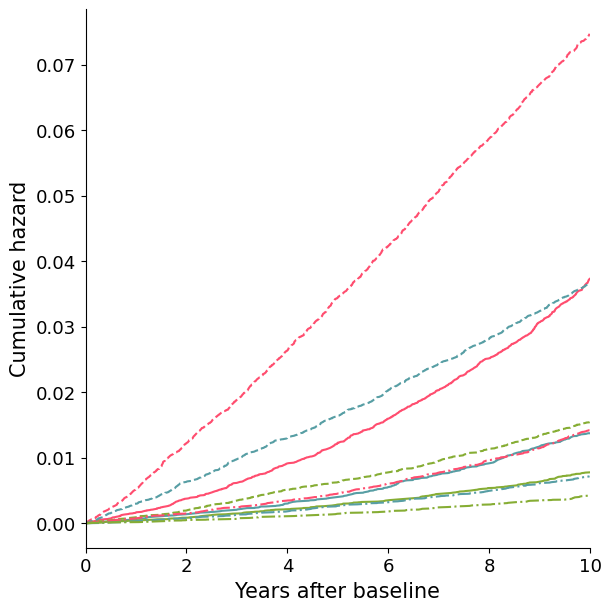

In [55]:
plt.figure(figsize=(6, 6), constrained_layout=True)
for j, (disease, scores) in enumerate(res_collect.items()):
    for i, risk_group in enumerate(['Top risk PRS', 'Mid risk PRS', 'Low risk PRS']):
        cum_hazard = scores['cum_hazard'][risk_group]
        plt.plot(cum_hazard.index, cum_hazard.values, 
            label=f'{risk_group} - {disease}', 
            color=res_colours[i], 
            linestyle=line_styles[j])

# plt.title(f'{model} for {disease} [Sex: {sex}]', fontsize=16)
plt.xlabel('Years after baseline', fontsize=15)
plt.ylabel('Cumulative hazard', fontsize=15)
plt.xlim(0, ending_year)  
# plt.legend(title='PRS risk group', fontsize=13, title_fontsize=15)
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.grid(False)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

Text(0.5, 1.0, 'Prevalence Comparison Across Diseases and Sex Categories')

<Figure size 640x480 with 0 Axes>

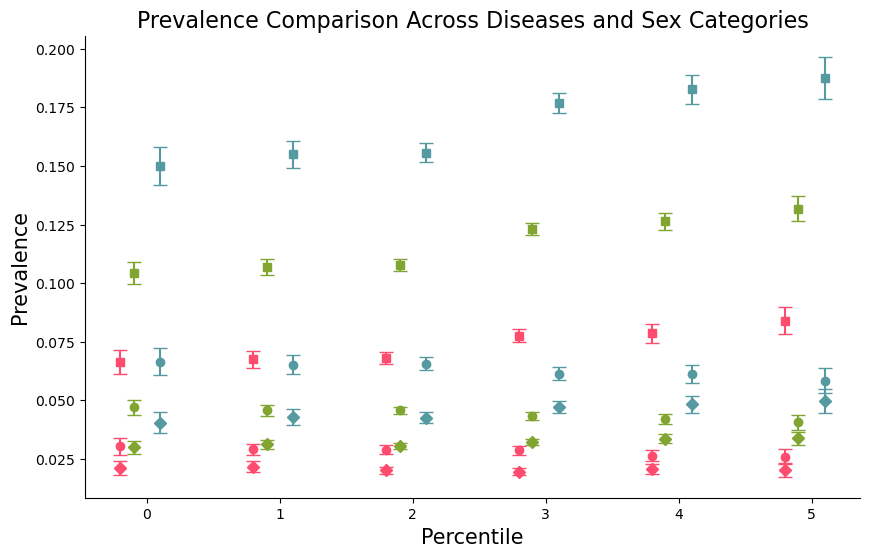

In [81]:
res_keys=['PRS_Female', 'PRS', 'PRS_Male']
res_labels=['Female', 'Both', 'Male']
res_colours=colour_prevalence[:3]
res_fmts=markers[:4]

# plotdelta = generate_sequence_plotdelta(len(res_keys))
plotdelta = generate_sequence_plotdelta(4)

plt.figure(constrained_layout=True)
fig, ax = plt.subplots(figsize=(10, 6))

# Loop over each disease
for j, disease in enumerate(interesting_diseaseIDs):
    for i, sex_category in enumerate(res_labels):
        # Fetch the current prevalence and CI data
        prevalence_data = raw_prev[disease]["prevalence_data"].get(sex_category, [])
        ci_lower_data = raw_prev[disease]["ci_lower_data"].get(sex_category, [])
        ci_upper_data = raw_prev[disease]["ci_upper_data"].get(sex_category, [])
        
        # Check if data is available
        if len(prevalence_data) < 6 or len(ci_lower_data) < 6 or len(ci_upper_data) < 6:
            print(f"Data missing for {disease} - {sex_category}")
            continue  # Skip if data is incomplete

        # Bottom and top groups for current sex category
        bottom = prevalence_data[:3]
        bottom_cis_lower = ci_lower_data[:3]
        bottom_cis_upper = ci_upper_data[:3]
        top = prevalence_data[3:]
        top_cis_lower = ci_lower_data[3:]
        top_cis_upper = ci_upper_data[3:]

        # Ensure the lengths are correct before plotting
        if len(bottom) != 3 or len(top) != 3:
            print(f"Inconsistent data lengths for {disease} - {sex_category}")
            continue

        # Plot the error bars for each disease and sex category
        ax.errorbar(np.arange(len(bottom)) + plotdelta[i], bottom, 
                    yerr=[np.subtract(bottom, bottom_cis_lower), np.subtract(bottom_cis_upper, bottom)], 
                    fmt=res_fmts[j], color=res_colours[i], 
                    label=f'{disease} - {sex_category} (Bottom)', capsize=5)
        
        ax.errorbar(np.arange(len(top)) + 3 + plotdelta[i], top, 
                    yerr=[np.subtract(top, top_cis_lower), np.subtract(top_cis_upper, top)], 
                    fmt=res_fmts[j], color=res_colours[i], 
                    label=f'{disease} - {sex_category} (Top)', capsize=5)

# Add the overall prevalence line if needed
# ax.axhline(y=overall_prevalence, color='gray', linestyle='--')
# ax.axvline(x=mid_percentile, color='gray', linestyle='dotted')

# Customize the plot
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# ax.set_xticks(x_ticks)
# ax.set_xticklabels(x_labels, fontsize=13)
ax.set_xlabel('Percentile', fontsize=15)
ax.set_ylabel('Prevalence', fontsize=15)
ax.set_title('Prevalence Comparison Across Diseases and Sex Categories', fontsize=16)

# Add the legend
# ax.legend(fontsize=13, title_fontsize=15)


In [75]:
len(raw_prev)

10

In [69]:
prevalence_data

{'Female': [0.030501089324618737,
  0.029069434092081875,
  0.029040766011123216,
  0.028639412877701966,
  0.026431970643885097,
  0.02602912510033253],
 'Both': [0.04700720777185835,
  0.045785020369790035,
  0.04572234409276089,
  0.043418990911939834,
  0.042087120025070514,
  0.040614227514885616],
 'Male': [0.06648237733241188,
  0.06523842432619212,
  0.06568989944365734,
  0.061266802584747225,
  0.06116102280580511,
  0.058465791292328956]}

In [ ]:
plt.figure(figsize=(6, 6), constrained_layout=True)

cum_hazard_means = {risk_group: [] for risk_group in risk_groups}

for j, (disease, scores) in enumerate(res_collect.items()):
    for i, risk_group in enumerate(risk_groups):
        cum_hazard = scores['cum_hazard'][risk_group]
        cum_hazard_means[risk_group].append(cum_hazard.values)
        plt.plot(cum_hazard.index, cum_hazard.values, 
            label=f'{risk_group} - {disease}', 
            color=res_colours[i], 
            linestyle=line_styles[j],
            alpha=0.4  # Faded lines
            )
        
for i, risk_group in enumerate(risk_groups):
    df_cum_hazard = pd.DataFrame(cum_hazard_means[risk_group]).mean(axis=0)
    plt.plot(
        cum_hazard.index, 
        df_cum_hazard, 
        label=risk_group, 
        color=res_colours[i], 
        linestyle='-', 
        linewidth=2.5,  # Thicker line for mean
        alpha=1  # Solid, prominent line
    )

# plt.title(f'{model} for {disease} [Sex: {sex}]', fontsize=16)
plt.xlabel('Years after baseline', fontsize=15)
plt.ylabel('Cumulative hazard', fontsize=15)
plt.xlim(0, ending_year)  
# plt.legend(title='PRS risk group', fontsize=13, title_fontsize=15)
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.grid(False)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

In [57]:
scores.keys()

dict_keys(['Type', 'Disease', 'Sex', 'cum_disease_burden', 'cum_hazard', 'KM_survival'])

In [39]:
res_collect['Atherosclerotic']['cum_hazard']['Top risk PRS'].values

array([[0.00000000e+00],
       [4.33252099e-05],
       [6.49885187e-05],
       ...,
       [7.46121605e-02],
       [7.46821836e-02],
       [7.47055257e-02]])